<a href="https://colab.research.google.com/github/ECV21/Machine-learning-/blob/main/Linear_Regression_with_PyTorch_IBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression in 1D Prediction

In [1]:
# These are the libraries will be used for this lab.

import torch

## Predition

Let us create the following expressions:
b= -1 ; w= 2
y_hat = -1 + 2x

In [2]:
# Define w = 2 and b = -1 for y = wx + b

w = torch.tensor(2.0, requires_grad = True)
b = torch.tensor(-1.0, requires_grad = True)

In [3]:
# Function forward(x) for prediction

def forward(x):
    yhat = w * x + b
    return yhat

In [4]:
# let's make predition at x=1

# y_hat = -1 + 2x
# y_hat = -1 + 2(1)


# Predict y = 2x - 1 at x = 1

x = torch.tensor([[1.0]])
yhat = forward(x)
print("The prediction: ", yhat)

The prediction:  tensor([[1.]], grad_fn=<AddBackward0>)


In [5]:
# Let us try to make the predition for multiple inputs


# Create x Tensor and check the shape of x tensor
x = torch.tensor([[1.0], [2.0]])
print("The shape of x: ", x.shape)


#make the predition
yhat = forward(x)
print("The prediction: ", yhat)

The shape of x:  torch.Size([2, 1])
The prediction:  tensor([[1.],
        [3.]], grad_fn=<AddBackward0>)


In [6]:
# Practice: Make a prediction of y = 2x - 1 at x = [[1.0], [2.0], [3.0]]

x = torch.tensor([[1.0], [2.0], [3.0]])

yhat = forward(x)
print("The prediction: ", yhat)

The prediction:  tensor([[1.],
        [3.],
        [5.]], grad_fn=<AddBackward0>)


# Class linear

We can also use the linear class to build more complex models

En PyTorch, class Linear (parte de torch.nn) es una capa fundamental para crear modelos de regresión lineal o capas completamente conectadas (dense) en redes neuronales.



¿Para qué sirve nn.Linear?
Implementa una transformación lineal (como una regresión lineal):

Fórmula: y = x @ W.T + b

x: Datos de entrada (tensor).

W: Matriz de pesos (ajustable durante el entrenamiento).

b: Vector de bias (opcional).

Usos comunes:

Regresión lineal (ej: predecir precios de casas).

Capas ocultas en redes neuronales (ej: perceptrones multicapa).

In [7]:
# Import Class Linear

from torch.nn import Linear

In [8]:
# Set random seed
torch.manual_seed(1)

# Create Linear Regression Model, and print out the parameters

lr = Linear(in_features=1, out_features=1, bias=True)
print("Parameters w and b: ", list(lr.parameters()))


Parameters w and b:  [Parameter containing:
tensor([[0.5153]], requires_grad=True), Parameter containing:
tensor([-0.4414], requires_grad=True)]


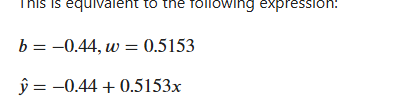

In [9]:
# A method "state_dict()" returns a Python dictionary object corresponding to the layers of each parameters tensor

print("Python dictionary: ",lr.state_dict())
print("keys: ",lr.state_dict().keys())
print("values: ",lr.state_dict().values())

Python dictionary:  OrderedDict([('weight', tensor([[0.5153]])), ('bias', tensor([-0.4414]))])
keys:  odict_keys(['weight', 'bias'])
values:  odict_values([tensor([[0.5153]]), tensor([-0.4414])])


In [10]:
# the keys correspond to the name of the atributes and the values correspond to the parameters value

print("weight:",lr.weight)
print("bias:",lr.bias)

weight: Parameter containing:
tensor([[0.5153]], requires_grad=True)
bias: Parameter containing:
tensor([-0.4414], requires_grad=True)


In [11]:
#make a single predition at x = [[1.0]]

x = torch.tensor([[1.0]])
yhat = lr(x)
print("The predition of the model: ", yhat)

The predition of the model:  tensor([[0.0739]], grad_fn=<AddmmBackward0>)


In [12]:
# We can make multiple preditions:

x = torch.tensor([[1.0], [2.0]])
yhat = lr(x)
print("The predition is: ", yhat)

The predition is:  tensor([[0.0739],
        [0.5891]], grad_fn=<AddmmBackward0>)


In [13]:
# Practice: Use the linear regression model object lr to make the prediction.

x = torch.tensor([[1.0],[2.0],[3.0]])

x=torch.tensor([[1.0],[2.0],[3.0]])
yhat = lr(x)
print("The prediction: ", yhat)

The prediction:  tensor([[0.0739],
        [0.5891],
        [1.1044]], grad_fn=<AddmmBackward0>)


# Build custom modules

We can make more complex models by using this method later on.

In [14]:
from torch import nn

In [19]:
# Let us difine the class

# Customize Linear Regression Class
class LR(nn.Module): ##hereda de la clase base "nn.Module"; nn.module es clase base de PyTorch

    # Constructor
    def __init__(self, input_size, output_size):

        # Inherit from parent
        super(LR, self).__init__()  # Llama al constructor de la clase padre (nn.Module)
        self.linear = nn.Linear(input_size, output_size) #Es la capa que hace la regresión lineal (como una ecuación y = mx + b pero en múltiples dimensiones)

    # Prediction function
    def forward(self, x):
        out = self.linear(x) # Pasa el tensor "x" por la capa lineal
        return out

In [20]:
# Create an objet by using the constructor

# Create the linear regression model. Print out the parameters.

lr = LR(1, 1)
print("The parameters: ", list(lr.parameters()))
print("Linear model: ", lr.linear)

The parameters:  [Parameter containing:
tensor([[-0.9414]], requires_grad=True), Parameter containing:
tensor([0.5997], requires_grad=True)]
Linear model:  Linear(in_features=1, out_features=1, bias=True)


## Let us try to make a predition of a single input sample


In [17]:
# Try our customize linear regression model with single input

x = torch.tensor([[1.0]])
yhat = lr(x)
print("The prediction: ", yhat)

The prediction:  tensor([[0.2755]], grad_fn=<AddmmBackward0>)


In [18]:
# Try our customize linear regression model with multiple input

x = torch.tensor([[1.0], [2.0]])
yhat = lr(x)
print("The prediction: ", yhat)

The prediction:  tensor([[0.2755],
        [0.0816]], grad_fn=<AddmmBackward0>)


#